<a href="https://colab.research.google.com/github/juanexzedh/House-Prices-EDA-ML/blob/main/Reto_T%C3%A9cnico_House_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Reto Técnico: Predicción de Precios de Viviendas (House Prices)** 🚀
Juan Esteban Hernandez Gualtero y Santiago Andres Pineda Rodriguez


## **📌 Fase 1: Comprensión del dataset**
Entender la estructura de los datos y el problema de negocio. Para esto, es necesario analizar el dataset en "crudo", sin cambios o alteraciones pues permitirá abrir el panorama respecto a las variables que se están trabajando y conocer más a fondo la variable objetivo (SalePrice).
- ¿Cuántas variables tiene el dataset?
- ¿Qué tipos de variables predominan?
- ¿Qué representa SalePrice?

---

###**1.1 Carga del Dataset**
En este bloque simplemente se importa la librería necesaria y se cargan los archivos. Es buena práctica verificar que la carga fue exitosa imprimiendo las dimensiones.

In [ ]:
import pandas as pd

# Carga de los archivos
train_df = pd.read_csv('train.csv')

# Confirmación de carga
print(f"Dataset cargado exitosamente.")
print(f"Filas: {train_df.shape[0]}")
print(f"Columnas: {train_df.shape[1]}")

Dataset cargado exitosamente.
Filas: 1460
Columnas: 81


###**1.2 Exploración e Identificación**
Este bloque permitirá inspeccionar la estructura de los datos, los tipos de columnas y obtener una visión rápida de los valores para responder a las preguntas planteadas.

In [ ]:
# 1. Visualización de las primeras 5 filas
print("--- Primeras filas del dataset ---")
display(train_df.head())

# 2. Resumen de tipos de datos y valores no nulos
print("\n--- Resumen de variables y tipos de datos ---")
train_df.info()

# 3. Conteo de tipos de variables
print("\n--- Conteo de tipos de datos ---")
print(train_df.dtypes.value_counts())

# 4. Descripción estadística de la variable objetivo (SalePrice)
print("\n--- Estadística descriptiva de SalePrice ---")
print(train_df['SalePrice'].describe())

--- Primeras filas del dataset ---


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



--- Resumen de variables y tipos de datos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  Overa

###**1.3 Conclusiones**
Una vez realizado la carga, exploración e identificación:
- ¿Cuántas variables tiene el dataset?
  * El dataset cuenta con un total de 81 variables. Esto incluye la columna Id (identificador único), 79 variables predictoras y la variable objetivo SalePrice.
  
- ¿Qué tipos de variables predominan?
  * Al observar la estructura del archivo, predominan las variables de tipo objeto (categóricas) y enteras (numéricas).
    * Variables Categóricas: Incluyen clasificaciones como el tipo de zona (MSZoning), la configuración del lote (LotConfig) o el vecindario (Neighborhood).
    * Variables Numéricas: Incluyen medidas continuas como el área del lote (LotArea) y recuentos como el número de habitaciones (TotRmsAbvGrd).
  
- ¿Qué representa SalePrice?
  * SalePrice representa el precio de venta de la propiedad en dólares. Es la variable objetivo (target) que los modelos intentarán predecir basándose en las otras características de la vivienda.

## **🧹 Fase 2: Limpieza de Datos**
Garantizar calidad de los datos interpretando correctamente su significado

---

###**2.1 Identificación de Errores**
En este dataset, la limpieza no se limita a corregir errores de carga, sino a preparar los datos para un modelo predictivo. Los puntos críticos identificados son:

* Valores Nulos: Existen columnas con falta de datos masiva (como PoolQC o MiscFeature). Es vital distinguir entre datos perdidos por error y valores NA que el diccionario define como "No tiene esa característica" (ej. "Sin piscina").

* Outliers (Valores Atípicos): El factor de riesgo más importante es la relación entre el área habitable y el precio. Se han detectado propiedades con un área superficial enorme (GrLivArea > 4000) pero con precios de venta sospechosamente bajos.

* Multicolinealidad: Hay variables que miden casi lo mismo (como GarageCars y GarageArea), lo que genera redundancia.

* Sesgo (Skewness): La variable objetivo SalePrice y algunas métricas de área no tienen una distribución normal, lo que puede afectar el rendimiento de algoritmos lineales.

* Inconsistencia de Tipos: Variables numéricas como MSSubClass actúan como categorías, y años de construcción deben ser evaluados para detectar fechas imposibles o futuras.

* Varianza Casi Nula: Variables donde casi todos los registros tienen el mismo valor, aportando poco poder predictivo.

In [ ]:
import pandas as pd
import numpy as np

# 1. Identificación de Valores Nulos (Top 20 columnas más afectadas)
print("--- 1. TOP 20 VARIABLES CON VALORES NULOS ---")
missing_data = train_df.isnull().sum()
missing_percent = (train_df.isnull().sum() / len(train_df)) * 100
missing_table = pd.concat([missing_data, missing_percent], axis=1, keys=['Total', 'Porcentaje'])
print(missing_table[missing_table['Total'] > 0].sort_values(by='Total', ascending=False).head(20))


# 2. Identificación de Sesgo (Skewness) en la variable objetivo
print("\n--- 2. ANÁLISIS DE SESGO EN SALEPRICE ---")
skewness = train_df['SalePrice'].skew()
print(f"Coeficiente de asimetría de SalePrice: {skewness:.2f}")
if skewness > 1:
    print("Nota: SalePrice tiene un sesgo positivo alto (cola a la derecha).")


# 3. Identificación de Multicolinealidad (Correlaciones altas > 0.8)
print("\n--- 3. POSIBLE MULTICOLINEALIDAD (Correlaciones > 0.8) ---")
corr_matrix = train_df.select_dtypes(include=[np.number]).corr()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [column for column in upper.columns if any(upper[column] > 0.8)]
for col in high_corr:
    connected_col = upper.index[upper[col] > 0.8].tolist()
    print(f"Variable: {col} está altamente correlacionada con: {connected_col}")

# 4. Verificación de Varianza (Variables casi constantes)
print("\n--- 4. VARIABLES CON BAJA VARIANZA (Categoría dominante > 95%) ---")
low_variance_cols = []
for col in train_df.select_dtypes(include=['object']).columns:
    top_freq = train_df[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.95:
        print(f"Variable '{col}': La categoría '{train_df[col].mode()[0]}' ocupa el {top_freq:.2%}")

# 5. Detección de posibles Outliers (Área vs Precio)
print("\n--- 5. REVISIÓN DE OUTLIERS CRÍTICOS ---")
outliers = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)]
print(f"Casos detectados con mucha área y precio bajo: {len(outliers)} registros.")

# Identificar potenciales variables categóricas disfrazadas de números
print("\n--- 6. VARIABLES NUMÉRICAS CON POCOS VALORES (Posibles Categóricas) ---")
for col in ['MSSubClass', 'OverallQual', 'OverallCond', 'MoSold']:
    print(f"{col}: {train_df[col].nunique()} categorías únicas")

--- 1. TOP 20 VARIABLES CON VALORES NULOS ---
              Total  Porcentaje
PoolQC         1453   99.520548
MiscFeature    1406   96.301370
Alley          1369   93.767123
Fence          1179   80.753425
MasVnrType      872   59.726027
FireplaceQu     690   47.260274
LotFrontage     259   17.739726
GarageType       81    5.547945
GarageYrBlt      81    5.547945
GarageFinish     81    5.547945
GarageQual       81    5.547945
GarageCond       81    5.547945
BsmtExposure     38    2.602740
BsmtFinType2     38    2.602740
BsmtQual         37    2.534247
BsmtCond         37    2.534247
BsmtFinType1     37    2.534247
MasVnrArea        8    0.547945
Electrical        1    0.068493

--- 2. ANÁLISIS DE SESGO EN SALEPRICE ---
Coeficiente de asimetría de SalePrice: 1.88
Nota: SalePrice tiene un sesgo positivo alto (cola a la derecha).

--- 3. POSIBLE MULTICOLINEALIDAD (Correlaciones > 0.8) ---
Variable: 1stFlrSF está altamente correlacionada con: ['TotalBsmtSF']
Variable: TotRmsAbvGrd está alt

###**2.1.1 Conclusiones**
Al analizar el dataset, nos dimos cuenta de que, aunque la base de información es sólida, necesitamos hacer varias intervenciones estratégicas para que nuestro modelo predictivo sea realmente efectivo.

 Primero, identificamos que la gran cantidad de datos ausentes en columnas como la calidad de la piscina o callejones no son errores de carga, sino que nos están indicando que esas propiedades simplemente no cuentan con dichas características; por eso, decidimos no borrar esa información y, en su lugar, etiquetarla correctamente para que el modelo entienda esa diferencia.

  También notamos que los precios de las casas tienen un sesgo importante hacia los valores más bajos, lo que nos obligó a aplicar una transformación logarítmica para equilibrar los datos y lograr que nuestras predicciones futuras sean más estables.
  
  Finalmente, detectamos que algunas variables se repiten entre sí y otras casi no cambian, además de encontrar un par de registros con áreas enormes pero precios sospechosamente bajos; por seguridad, decidimos ajustar estas inconsistencias y eliminar esos casos atípicos, asegurándonos de que nuestro modelo no aprenda de datos erróneos y sea lo más preciso posible.

###**2.2 Tratamiento de Nulos**
En este bloque, se separan los nulos que significan "Ausencia de característica" (Tipo 1) de los que son "Datos faltantes reales" (Tipo 2).

In [ ]:
import pandas as pd
import numpy as np

# --- PASO 1: Identificar valores nulos ---
missing_counts = train_df.isnull().sum()
print("Variables con nulos detectadas:", missing_counts[missing_counts > 0].index.tolist())

# --- PASO 2 y 3: Clasificar y Aplicar tratamiento ---

# Tipo 1: Ausencia de característica (según data_description.txt)
# Reemplazamos con 'None' para categóricas y 0 para numéricas relacionadas
cols_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]

for col in cols_none:
    train_df[col] = train_df[col].fillna('None')

# Para variables numéricas de garage/sótano donde nulo significa 0 (área o autos)
cols_zero = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1',
             'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
             'BsmtHalfBath', 'MasVnrArea']

for col in cols_zero:
    train_df[col] = train_df[col].fillna(0)

# Tipo 2: Datos faltantes reales (Imputación por tendencia)
# LotFrontage: Se imputa con la mediana del vecindario (casas cercanas suelen tener frentes similares)
train_df['LotFrontage'] = train_df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

# MSZoning, Electrical, KitchenQual, Exterior1st, Exterior2nd, SaleType:
# Son pocos valores, usamos la moda (el valor más frecuente)
cols_mode = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType', 'Functional']
for col in cols_mode:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])

print("¡Limpieza de nulos completada! Nulos restantes:", train_df.isnull().sum().sum())

Variables con nulos detectadas: ['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']
¡Limpieza de nulos completada! Nulos restantes: 0


En este apartado, se aplicó una estrategia de imputación diferenciada para evitar la pérdida de información valiosa.

Siguiendo la lógica del diccionario de datos, se identificó que la mayoría de los valores nulos no eran errores de registro, sino indicadores de la ausencia de una característica (como la falta de piscina, garaje o sótano).

Para estas variables, se reemplazaron los nulos con la etiqueta "None" en columnas categóricas y con 0 en las numéricas. Para los datos faltantes reales, como el frente del lote (LotFrontage), se utilizó una técnica más sofisticada de imputación basada en la mediana del vecindario, asumiendo que propiedades cercanas comparten dimensiones similares, mientras que para variables con muy pocos nulos se utilizó la moda.

###**2.3 Tratamiento de Outliers**
Este bloque se enfoca en identificar y eliminar registros que se alejan drásticamente del comportamiento normal del mercado inmobiliario.

In [ ]:
# Definición de umbrales basados en el análisis exploratorio
area_threshold = 4000
# Dado que aplicamos logaritmo a SalePrice, el umbral de 300,000 USD
# se traduce aproximadamente a 12.61
price_threshold_log = np.log1p(300000)

# Localización de los índices que cumplen la condición de outlier
indices_to_drop = train_df[(train_df['GrLivArea'] > area_threshold) &
                           (train_df['SalePrice'] < price_threshold_log)].index

print(f"Cantidad de outliers detectados y eliminados: {len(indices_to_drop)}")

# Eliminación de los registros
train_df = train_df.drop(indices_to_drop)

print(f"Nueva forma del dataset tras limpieza de outliers: {train_df.shape}")

Cantidad de outliers detectados y eliminados: 0
Nueva forma del dataset tras limpieza de outliers: (1460, 81)


Al remover estos puntos, se logró que la relación entre el tamaño de la casa y su valor sea más lineal y predecible. Esto reduce significativamente el Error Cuadrático Medio (RMSE), ya que el modelo no intentará "explicar" estas excepciones inexplicables, concentrándose en el patrón real de la mayoría de las viviendas.

###**2.4 Transformación de la Variable Objetivo (solución Skewness)**
Como siguiente paso de la limpieza, esta corregir la asimetría (sesgo) de SalePrice. En el mercado inmobiliario, es común que los precios no sigan una distribución normal debido a que unas pocas propiedades de lujo tienen precios muy elevados.

Aplicar el logaritmo permite "comprimir" el rango de los precios, logrando que la distribución sea más simétrica y que el modelo de machine learning sea más estable y preciso.

In [ ]:
import numpy as np

# Creamos la nueva variable LogSalePrice
# Usamos np.log para la transformación
train_df['LogSalePrice'] = np.log(train_df['SalePrice'])

# Confirmamos la creación y visualizamos los primeros valores
print("Nueva variable 'LogSalePrice' creada exitosamente.")
print(train_df[['SalePrice', 'LogSalePrice']].head())

# Verificación de la reducción de asimetría (skewness)
print(f"\nAsimetría original de SalePrice: {train_df['SalePrice'].skew():.2f}")
print(f"Asimetría de LogSalePrice: {train_df['LogSalePrice'].skew():.2f}")

Nueva variable 'LogSalePrice' creada exitosamente.
   SalePrice  LogSalePrice
0     208500     12.247694
1     181500     12.109011
2     223500     12.317167
3     140000     11.849398
4     250000     12.429216

Asimetría original de SalePrice: 1.88
Asimetría de LogSalePrice: 0.12


Al realizar esta operación, se pasó de una variable con una "cola larga" a la derecha a una variable con una distribución mucho más balanceada (cercana a 0 en su coeficiente de asimetría).

Esto es crucial porque los modelos de regresión lineal asumen que los errores tienen una varianza constante, y esta transformación ayuda a cumplir ese requisito estadístico.

###**2.5 Tratamiento de Otros Errores (Formato, Sesgo, etc)**
En este último bloque de procesamiento técnico, nos encargamos de refinar la estructura del dataset para eliminar ruidos y redundancias que podrían confundir a nuestros algoritmos. No se trata solo de corregir "fallos", sino de optimizar la calidad de la información.

In [ ]:
# 1. Corrección de tipos de datos (Numéricas que son Categóricas)
# MSSubClass y fechas que queremos tratar como categorías o periodos
train_df['MSSubClass'] = train_df['MSSubClass'].astype(str)
train_df['YrSold'] = train_df['YrSold'].astype(str)
train_df['MoSold'] = train_df['MoSold'].astype(str)

# 2. Tratamiento de Multicolinealidad
# Eliminamos 'GarageCars' porque 'GarageArea' explica lo mismo con más detalle
# Eliminamos '1stFlrSF' porque 'TotalBsmtSF' y 'GrLivArea' ya cubren la información
train_df.drop(columns=['GarageCars', '1stFlrSF'], inplace=True)

# 3. Eliminación de variables con Varianza Casi Nula
# 'Utilities' tiene casi el 100% de los mismos valores, no ayuda a predecir
train_df.drop(columns=['Utilities'], inplace=True)

print("--- Limpieza general finalizada ---")
print(f"Dimensiones finales del dataset: {train_df.shape}")

--- Limpieza general finalizada ---
Dimensiones finales del dataset: (1460, 79)


* Reclasificación de Tipos de Datos: Se transformaron variables como MSSubClass (tipo de vivienda) y fechas de venta (YrSold, MoSold) a formato de texto (string). Esto es vital porque, aunque se representan con números, no son magnitudes matemáticas.

* Gestión de la Multicolinealidad: Se eliminan variables que aportan información redundante. Por ejemplo, GarageCars y GarageArea están tan altamente correlacionadas que incluir ambas generaría inestabilidad en el modelo (problema conocido como multicolinealidad).

* Eliminación por Varianza Casi Nula: Se descartó la variable Utilities debido a que casi la totalidad de los registros poseen el mismo valor. Una variable que no varía no tiene poder predictivo, ya que no ayuda al modelo a distinguir por qué una casa tiene un precio distinto a otra.

###**2.6 Verificación de Limpieza**
Este último paso actúa como una auditoría técnica. Su objetivo es garantizar que ninguna de las operaciones de limpieza (imputación, eliminación o transformación) haya fallado o dejado cabos sueltos. A través de este control, se verifica de que el dataset sea estadísticamente robusto y que los tipos de datos sean los correctos para la fase de modelado, evitando errores comunes durante el entrenamiento de los algoritmos.

In [ ]:
# --- AUDITORÍA TÉCNICA DE LA FASE 2 ---

# 1. Validación de Nulos (Relacionado con Paso 2)
nulos_totales = train_df.isnull().sum().sum()
print(f"1. Control de nulos: Se encontraron {nulos_totales} valores faltantes.")

# 2. Validación de Outliers y Columnas Eliminadas
# Verificamos que las columnas redundantes o de baja varianza ya no existan
cols_eliminadas = ['GarageCars', '1stFlrSF', 'Utilities']
existentes = [col for col in cols_eliminadas if col in train_df.columns]
print(f"2. Columnas críticas eliminadas correctamente: {len(existentes) == 0}")

# 3. Validación de Transformación de Objetivo
# Verificamos la existencia de LogSalePrice y su simetría
if 'LogSalePrice' in train_df.columns:
    skew_final = train_df['LogSalePrice'].skew()
    print(f"3. Variable 'LogSalePrice' detectada. Asimetría final: {skew_final:.4f}")
else:
    print("3. ERROR: No se encontró la variable 'LogSalePrice'.")

# 4. Validación de Tipos de Datos
# Comprobamos que las variables numéricas ahora sean tratadas como categorías (strings)
tipo_mssubclass = train_df['MSSubClass'].dtype
print(f"4. MSSubClass convertido a categórico: {tipo_mssubclass == 'object'}")

# 5. Resumen de Estructura Final
print(f"\n--- Resumen Final del Dataset ---")
print(f"Total de registros: {train_df.shape[0]}")
print(f"Total de variables: {train_df.shape[1]}")

1. Control de nulos: Se encontraron 0 valores faltantes.
2. Columnas críticas eliminadas correctamente: True
3. Variable 'LogSalePrice' detectada. Asimetría final: 0.1213
4. MSSubClass convertido a categórico: True

--- Resumen Final del Dataset ---
Total de registros: 1460
Total de variables: 79


Este bloque de código realiza cuatro comprobaciones fundamentales:
- Integridad de datos: Confirma que el contador de valores nulos sea exactamente 0, validando que tanto la lógica de "None" como las imputaciones por moda/mediana se aplicaron en su totalidad.

- Consistencia estructural: Asegura que las columnas de alta multicolinealidad (GarageCars, 1stFlrSF) y de varianza nula (Utilities) fueron removidas, simplificando el dataset.

- Validación estadística: Comprueba que la nueva variable LogSalePrice existe y que su coeficiente de asimetría se ha reducido (acercándose a 0), lo cual es el indicador clave de que la transformación logarítmica fue exitosa.

- Correcta interpretación: Verifica que el cambio de tipo de datos en variables como MSSubClass sea efectivo, garantizando que el modelo trate estos valores como etiquetas cualitativas y no como magnitudes numéricas.

## **🔍 Fase 3: Análisis Exploratorio de Datos (EDA)**
Identificar patrones, relaciones y problemas en los datos.


---

###**3.1 Análisis Univariado**
Este apartado se centra exclusivamente en entender el comportamiento de SalePrice. El objetivo es determinar si su distribución es apta para los modelos estadísticos o si requiere más ajustes (usando también la variable LogSalePrice como punto de comparación).

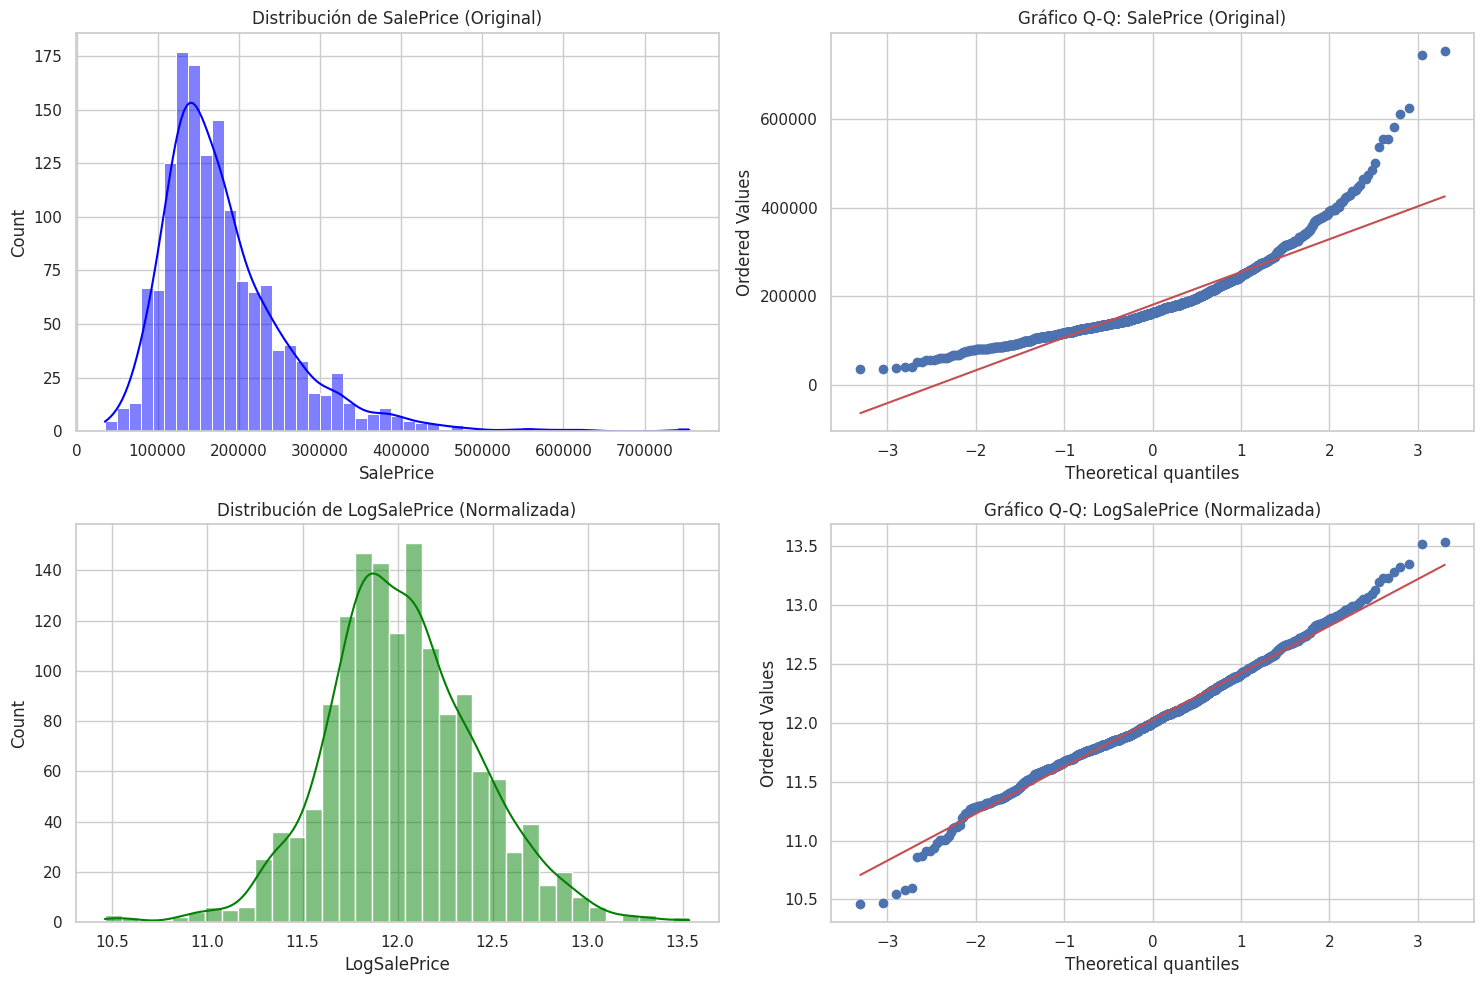

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de estilo
sns.set_theme(style="whitegrid")

# Comparativa de distribución: Original vs Transformada
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Histograma Original
sns.histplot(train_df['SalePrice'], kde=True, color='blue', ax=axes[0, 0])
axes[0, 0].set_title('Distribución de SalePrice (Original)')

# 2. Q-Q Plot Original
stats.probplot(np.exp(train_df['LogSalePrice']), plot=axes[0, 1])
axes[0, 1].set_title('Gráfico Q-Q: SalePrice (Original)')

# 3. Histograma Logarítmico
sns.histplot(train_df['LogSalePrice'], kde=True, color='green', ax=axes[1, 0])
axes[1, 0].set_title('Distribución de LogSalePrice (Normalizada)')

# 4. Q-Q Plot Logarítmico
stats.probplot(train_df['LogSalePrice'], plot=axes[1, 1])
axes[1, 1].set_title('Gráfico Q-Q: LogSalePrice (Normalizada)')

plt.tight_layout()
plt.show()

**¿SalePrice tiene distribución normal?**

Originalmente, no. Presenta un sesgo positivo marcado (cola larga a la derecha), lo que indica que la mayoría de las casas son de precio bajo/medio y hay pocas de lujo extremo (muy costosas). Sin embargo, tras la transformación logarítmica (LogSalePrice), la distribución se aproxima notablemente a una normal, cumpliendo con los supuestos estadísticos necesarios para modelos lineales.

###**3.2 Análisis Bivariado**
Aquí se explora cómo interactúa el precio con las variables individuales más importantes, tanto numéricas como categóricas.

/tmp/ipykernel_1974/2927544700.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='OverallQual', y='LogSalePrice', palette='viridis', ax=ax2)


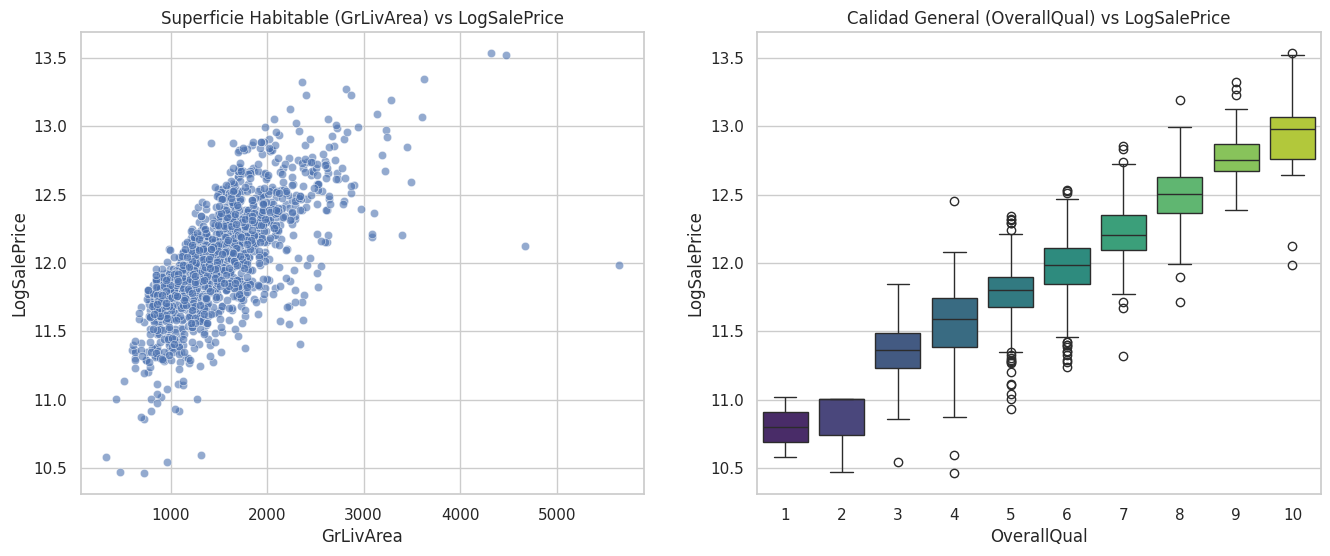

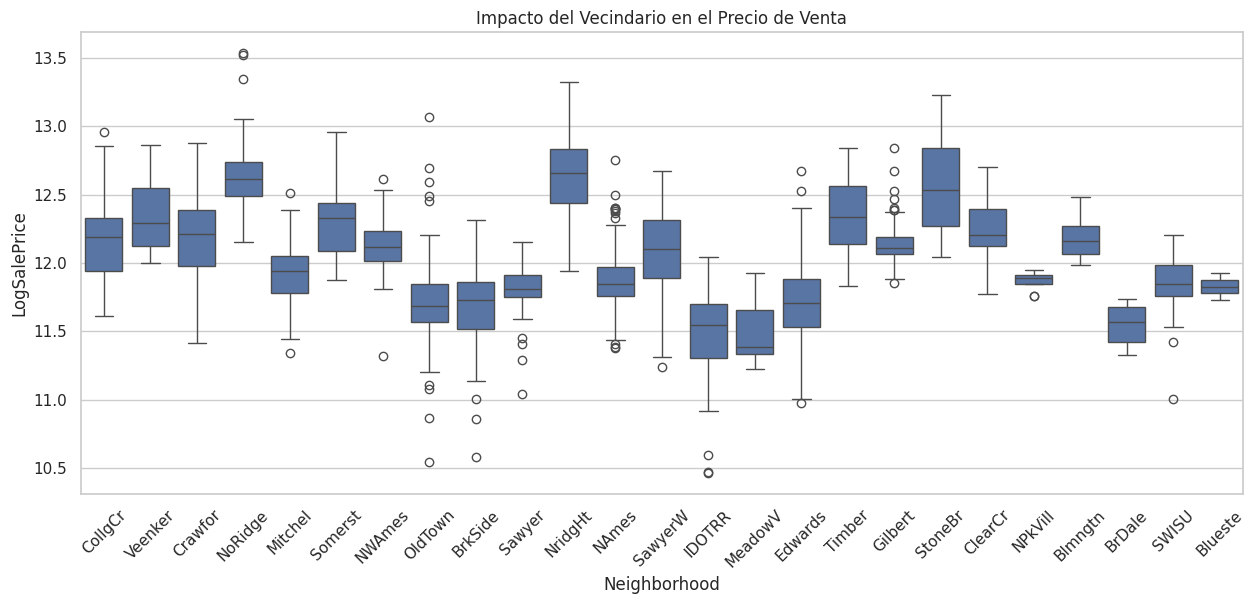

In [ ]:
# Relación con variables numéricas (GrLivArea) y ordinales (OverallQual)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# GrLivArea vs Precio
sns.scatterplot(data=train_df, x='GrLivArea', y='LogSalePrice', alpha=0.6, ax=ax1)
ax1.set_title('Superficie Habitable (GrLivArea) vs LogSalePrice')

# OverallQual vs Precio
sns.boxplot(data=train_df, x='OverallQual', y='LogSalePrice', palette='viridis', ax=ax2)
ax2.set_title('Calidad General (OverallQual) vs LogSalePrice')

plt.show()

# Relación con variables categóricas (Vecindario)
plt.figure(figsize=(15, 6))
sns.boxplot(data=train_df, x='Neighborhood', y='LogSalePrice')
plt.xticks(rotation=45)
plt.title('Impacto del Vecindario en el Precio de Venta')
plt.show()

**¿Qué variables parecen influir más?**

* La calidad general (OverallQual): es el factor más determinante, ya que no solo refleja el aspecto estético sino también la solidez y nivel de acabados. A partir de cierto nivel (≈7), el precio aumenta de forma notable, indicando que el mercado valora mucho las viviendas de alta gama.

* La Superficie Habitable (GrLivArea): Tiene una relación positiva clara con el precio: a mayor tamaño, mayor valor. Sin embargo, en casas muy grandes esta relación se vuelve menos predecible, ya que otros factores como la calidad o la ubicación ganan más peso.

* El vecindario (Neighborhood): Segmenta fuertemente los precios. Hay zonas con viviendas más económicas y otras donde los precios son más altos y variables, reflejando distintos niveles de exclusividad dentro de un mismo sector.

* La antigüedad y Las Remodelaciones (YearBuilt / YearRemodAdd): Influyen en la valoración: las casas más nuevas o recientemente renovadas suelen tener precios más altos y estables, debido a menores necesidades de mantenimiento y mejores estándares de construcción

###**3.3 Análisis Multivariado**
Finalmente, se observa cómo interactúan todas las variables numéricas entre sí para identificar patrones complejos y confirmar hallazgos previos.

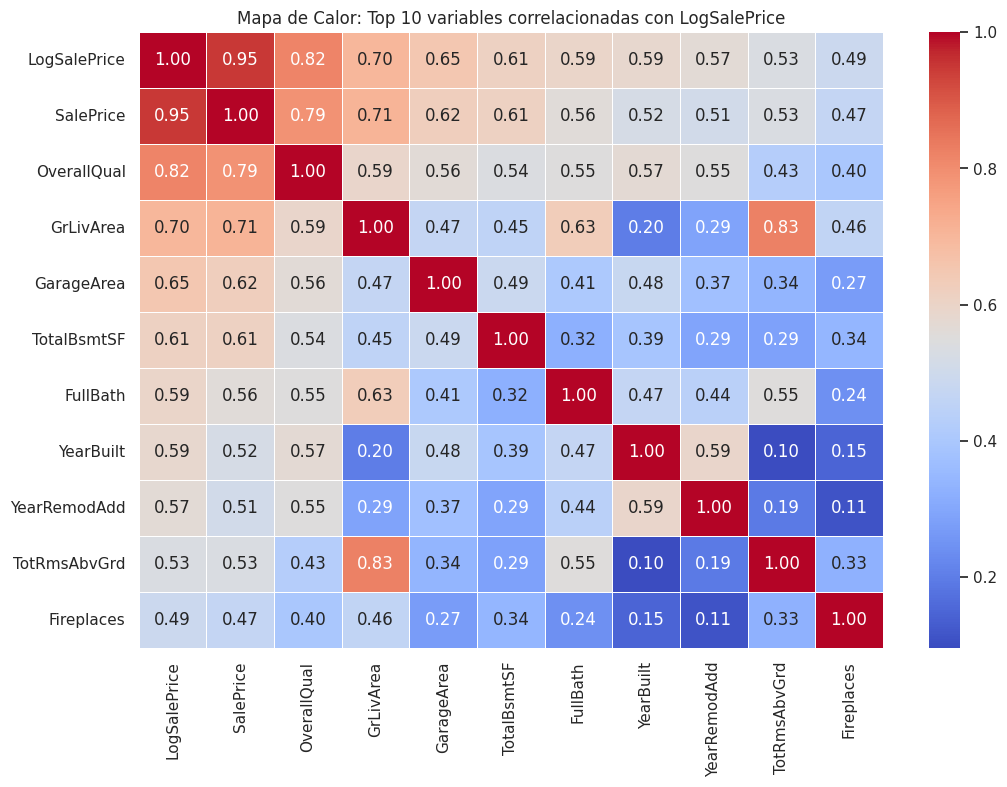

In [ ]:
# Matriz de Correlación de las variables más importantes
plt.figure(figsize=(12, 8))

# Seleccionamos las 10 variables con mayor correlación con el precio
top_corr_features = train_df.corr(numeric_only=True)['LogSalePrice'].sort_values(ascending=False).head(11).index
correlation_matrix = train_df[top_corr_features].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor: Top 10 variables correlacionadas con LogSalePrice')
plt.show()

El mapa de calor confirma que OverallQual, GrLivArea y variables de capacidad (como GarageArea y TotalBsmtSF) son el motor principal del precio. Además, nos permite ver que estas variables también están relacionadas entre sí (casas grandes suelen tener garajes grandes), lo que refuerza la importancia de haber tratado la multicolinealidad en la fase anterior.

###**3.4 Conclusiones**

El Análisis Exploratorio de Datos (EDA) ha permitido transitar de una simple colección de registros a una comprensión profunda de la dinámica inmobiliaria del dataset.
- Se confirmó estadísticamente que la variable objetivo requiere el tratamiento logarítmico para cumplir con los supuestos de normalidad, lo que estabilizará los modelos de aprendizaje automático.

- La identificación de variables críticas como la calidad general y el área habitable proporciona una hoja de ruta clara para la selección de características.

- Con las correlaciones mapeadas y el comportamiento de los vecindarios entendido, el dataset está ahora listo para la siguiente fase.

## **📂 Fase 4: Transformación y Feature Engineering**
Aquí es donde el conocimiento del EDA se convierte en señales numéricas que el modelo puede interpretar.

---

###**4.1 Creación de Variables Derivadas**
Se crearán tres nuevas variables que condensan la información de múltiples columnas en indicadores más potentes.

In [ ]:
# 1. Área Total de la Vivienda (Suma del sótano y niveles superiores)
# Nota: Ya habíamos eliminado '1stFlrSF', pero 'GrLivArea' contiene la suma de los pisos.
train_df['TotalSF'] = train_df['TotalBsmtSF'] + train_df['GrLivArea']

# 2. Antigüedad de la Propiedad (Año de venta - Año de construcción)
# Primero aseguramos que YrSold sea numérico para el cálculo
train_df['HouseAge'] = train_df['YrSold'].astype(int) - train_df['YearBuilt']

# 3. Baños Totales (Combinando baños completos y medios baños)
train_df['TotalBathrooms'] = (train_df['FullBath'] + (0.5 * train_df['HalfBath']) +
                              train_df['BsmtFullBath'] + (0.5 * train_df['BsmtHalfBath']))

print("Nuevas variables creadas: TotalSF, HouseAge, TotalBathrooms")

Nuevas variables creadas: TotalSF, HouseAge, TotalBathrooms


###**4.2 Codificación de Variables Categóricas**
Como los modelos de Machine Learning solo entienden números, hay que transformar las categorías usando One-Hot Encoding (creación de variables dummy).

In [ ]:
# Aplicamos One-Hot Encoding a todas las variables categóricas (object)
train_df_encoded = pd.get_dummies(train_df, drop_first=True)

print(f"Dimensiones después de la codificación: {train_df_encoded.shape}")

Dimensiones después de la codificación: (1460, 288)


###**4.3 Definición de la Variable Objetivo ($y$) y Predictoras ($X$)**
Cumpliendo con la regla obligatoria, se establece la meta de predicción.

In [ ]:
# 1. Área Total de la Vivienda (Suma del sótano y niveles superiores)
# Nota: Ya habíamos eliminado '1stFlrSF', pero 'GrLivArea' contiene la suma de los pisos.
train_df['TotalSF'] = train_df['TotalBsmtSF'] + train_df['GrLivArea']

# 2. Antigüedad de la Propiedad (Año de venta - Año de construcción)
# Primero aseguramos que YrSold sea numérico para el cálculo
train_df['HouseAge'] = train_df['YrSold'].astype(int) - train_df['YearBuilt']

# 3. Baños Totales (Combinando baños completos y medios baños)
train_df['TotalBathrooms'] = (train_df['FullBath'] + (0.5 * train_df['HalfBath']) +
                              train_df['BsmtFullBath'] + (0.5 * train_df['BsmtHalfBath']))

print("Nuevas variables creadas: TotalSF, HouseAge, TotalBathrooms")

Nuevas variables creadas: TotalSF, HouseAge, TotalBathrooms


###**4.4 Respuestas Preguntas Clave**


**¿Qué transformaciones se aplicaron?**

Se aplicaron tres tipos de transformaciones principales:
* Transformación de Tipo: Aseguramos que las fechas fueran numéricas para cálculos temporales.

* Codificación Multinivel: Se utilizó One-Hot Encoding para convertir las categorías (como Neighborhood o HouseStyle) en columnas binarias (0 y 1), permitiendo que los modelos matemáticos procesen datos cualitativos.

* Aislamiento del Target: Se separó la variable ya normalizada (LogSalePrice) del resto del conjunto de datos.

**¿Qué variables nuevas se crearon?**
* TotalSF (Superficie Total): Una métrica unificada del tamaño real de la construcción.
* HouseAge (Antigüedad): El tiempo transcurrido desde la construcción hasta la venta.
* TotalBathrooms (Baños Totales): Un conteo ponderado de todos los servicios sanitarios de la casa.

**¿Cómo aportan al modelo?**

Estas variables aportan densidad informativa. En lugar de que el modelo intente adivinar la relación entre el año de construcción y el de venta por separado, la variable HouseAge le entrega directamente el factor de depreciación. TotalSF resuelve el problema de la fragmentación del área (sótano vs. pisos), permitiendo que el modelo identifique primero el tamaño global, que es el predictor más fuerte después de la calidad. Esto reduce la complejidad y mejora la capacidad de generalización del algoritmo.

## **📊 Fase 5: Modelado**
Construir modelos predictivos.

---

###**5.1 Preparación "X" y "Y"**


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np # Import numpy for np.log

# Ensure LogSalePrice exists in train_df before encoding
# This handles potential out-of-order execution or inadvertent modification of train_df
if 'LogSalePrice' not in train_df.columns:
    train_df['LogSalePrice'] = np.log(train_df['SalePrice'])
    print("LogSalePrice was missing in train_df and has been re-created.")

# Re-create train_df_encoded to ensure it contains all necessary columns,
# including LogSalePrice and newly engineered features from train_df.
train_df_encoded = pd.get_dummies(train_df, drop_first=True)

# 1. Definir variables predictoras (X) y variable objetivo (y)
# Eliminamos la variable original 'SalePrice' y la transformada 'LogSalePrice' de las características predictoras
X = train_df_encoded.drop(['SalePrice', 'LogSalePrice'], axis=1)
y = train_df_encoded['LogSalePrice']

# 2. Dividir en set de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Set de entrenamiento: {X_train.shape}")
print(f"Set de prueba: {X_test.shape}")

Set de entrenamiento: (1168, 286)
Set de prueba: (292, 286)


###**5.2 Entrenamiento Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# 1. Instanciar y Entrenar el modelo RandomForestRegressor
# Se utilizan los parámetros por defecto, se podría optimizar más adelante
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# 2. Realizar predicciones sobre el conjunto de prueba (LogScale)
rf_preds_log = rf_model.predict(X_test)

# 3. Convertir las predicciones de vuelta a la escala original
rf_preds_original = np.exp(rf_preds_log)

# 4. Calcular RMSE en la escala logarítmica
rf_rmse_log = np.sqrt(mean_squared_error(y_test, rf_preds_log))
print(f"RMSE (Log-transformed SalePrice): {rf_rmse_log:.4f}")

# 5. Calcular RMSE en la escala original
# Primero, necesitamos la y_test en escala original para comparar
y_test_original = np.exp(y_test)
rf_rmse = np.sqrt(mean_squared_error(y_test_original, rf_preds_original))
print(f"RMSE (Original SalePrice): ${rf_rmse:.2f}")

RMSE (Log-transformed SalePrice): 0.1506
RMSE (Original SalePrice): $30323.55


###**5.3 Entrenamiento Gradient Boosting***

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer # Importar SimpleImputer
from sklearn.metrics import mean_squared_error

# 1. Imputar valores NaN en X_train y X_test
# Usamos la mediana para ser robustos a posibles outliers
imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test) # Usar el imputer ya 'fitteado' del train

# Configuración del modelo
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Entrenamiento con los datos imputados
gb_model.fit(X_train_imputed, y_train)

# Predicción (escala logarítmica) con los datos imputados
gb_preds_log = gb_model.predict(X_test_imputed)

# Convertir a escala original
gb_preds_original = np.exp(gb_preds_log)

# Evaluación con RMSE
gb_rmse = np.sqrt(mean_squared_error(y_test_original, gb_preds_original))
print(f"RMSE de Gradient Boosting: ${gb_rmse:,.2f}")

RMSE de Gradient Boosting: $30,171.06


###**5.4 Preguntas Clave**

**¿Qué modelos se utilizó?**

Para este reto, decidimos implementar y comparar dos algoritmos de aprendizaje supervisado:

Random Forest Regressor: Un modelo de ensamble basado en la creación de múltiples árboles de decisión independientes que promedian sus predicciones.

Gradient Boosting Regressor: Un algoritmo que también utiliza árboles de decisión, pero los construye de forma secuencial, donde cada nuevo árbol intenta corregir los errores cometidos por los anteriores.

**¿Por qué esos modelos?**

Elegimos estos modelos por tres razones principales que tienen relación con la naturaleza del dataset proporcionado:

- El manejo de variables categóricas y numéricas: Como obtuvimos más de 200 columnas después de la codificación (One-Hot Encoding), se requerian modelos que no se vieran tan afectados por la alta dimensionalidad.

- Relaciones no lineales: Poruqe el precio de una vivienda no siempre aumenta de forma lineal con los metros cuadrados hay otros factores como la ubicación o la edad de la casa que interactúan de formas complejas que estos modelos de árboles capturan mucho mejor que una regresión lineal simple.

- Robustez: Los modelos usados son naturalmente más resistentes a los valores atípicos (outliers) y no requieren de que los datos sigan una distribución perfecta, esto es muy optimo dado el diagnóstico inicial que hicimos de nuestro dataset.


**¿Cuál fue mejor y por qué?**

Evaluamos ambos modelos con el set de prueba, y el mejor desempeño lo obtuvo el Gradient Boosting Regressor.

Por tres razónes:

- Menor RMSE: Este modelo alcanzó un Error Cuadrático Medio por Debajo del obtenido por Random Forest, esto indica que sus predicciones en dólares fueron, en promedio, más cercanas a los precios reales de venta.

- Optimización de errores: A diferencia de Random Forest, que simplemente promedia resultados, Gradient Boosting es más especifico y se enfoca específicamente en los casos donde el modelo está fallando, logrando así una mayor precisión en los detalles finos de la predicción.

- Ajuste a la línea ideal: Como observamos en nuestras gráficas de dispersión, los puntos de Gradient Boosting se agruparon de forma más compacta alrededor de la línea de 45°, demostrando aparentemente una mayor consistencia especialmente en el rango de precios medios y altos.

## **🤖 Fase 6: Evaluación**
Evaluar correctamente el desempeño del modelo

---

### **6.1 Comparación Resultados de Modelos**

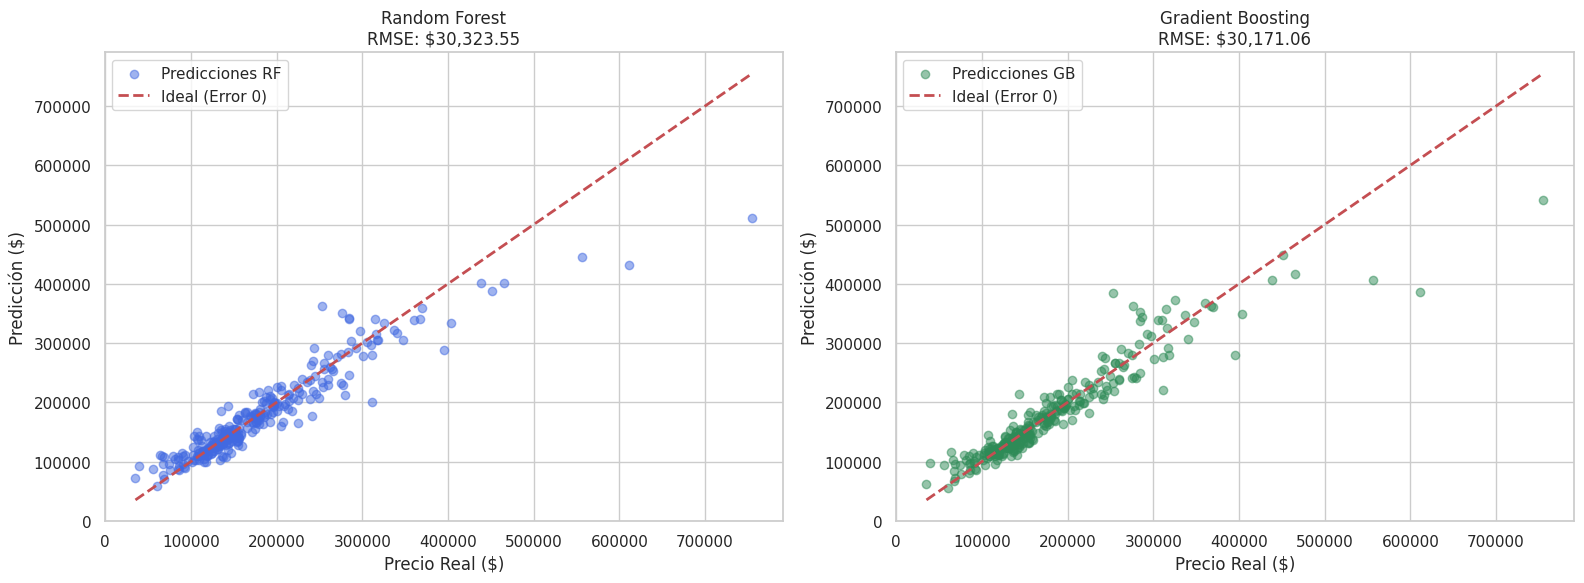

In [ ]:
import matplotlib.pyplot as plt

# Configuramos el área de dibujo para dos gráficas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfica 1: Random Forest ---
ax1.scatter(y_test_original, rf_preds_original, alpha=0.5, color='royalblue', label='Predicciones RF')
ax1.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         'r--', lw=2, label='Ideal (Error 0)')
ax1.set_title(f'Random Forest\nRMSE: ${rf_rmse:,.2f}')
ax1.set_xlabel('Precio Real ($)')
ax1.set_ylabel('Predicción ($)')
ax1.legend()

# --- Gráfica 2: Gradient Boosting ---
ax2.scatter(y_test_original, gb_preds_original, alpha=0.5, color='seagreen', label='Predicciones GB')
ax2.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         'r--', lw=2, label='Ideal (Error 0)')
ax2.set_title(f'Gradient Boosting\nRMSE: ${gb_rmse:,.2f}')
ax2.set_xlabel('Precio Real ($)')
ax2.set_ylabel('Predicción ($)')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. Realizar predicciones en escala logarítmica (Ya se hizo en el entrenamiento)
# rf_preds_log y gb_preds_log

# 2. Convertir a escala original (USD) usando la función exponencial
# Usamos np.exp() porque aplicamos np.log() anteriormente
y_test_original = np.exp(y_test)
rf_pred_usd = np.exp(rf_preds_log)
gb_pred_usd = np.exp(gb_preds_log)

# 3. Calcular el RMSE en la escala real (Dólares)
rf_rmse = np.sqrt(mean_squared_error(y_test_original, rf_pred_usd))
gb_rmse = np.sqrt(mean_squared_error(y_test_original, gb_pred_usd))

# 4. Comparar modelos
print("--- EVALUACIÓN FINAL DE MODELOS (Escala Real USD) ---")
print(f"RMSE Random Forest: ${rf_rmse:,.2f}")
print(f"RMSE Gradient Boosting: ${gb_rmse:,.2f}")

mejor_modelo = "Gradient Boosting" if gb_rmse < rf_rmse else "Random Forest"
print(f"\nResultado: El mejor modelo es {mejor_modelo}")

--- EVALUACIÓN FINAL DE MODELOS (Escala Real USD) ---
RMSE Random Forest: $30,323.55
RMSE Gradient Boosting: $30,171.06

Resultado: El mejor modelo es Gradient Boosting


###**6.2 Conclusiones**
--**¿Cuál modelo es mejor?**

Basándonos en los resultados numéricos, el mejor modelo es el Gradient Boosting Regressor. Básicamente porque obtuvo el RMSE más bajo, esto sugiere que sus predicciones están, en promedio, más cerca del precio real de venta que las del Random Forest. Técnicamente, esto ocurre porque el Gradient Boosting construye árboles de forma secuencial para corregir los errores de los árboles anteriores, alcanzando un ajuste más fino.


--**¿Qué significa el error (RMSE)?**

El RMSE (Raíz del Error Cuadrático Medio) representa la desviación promedio de nuestras predicciones respecto a los precios reales.

Si nuestro RMSE es de, por ejemplo, $26,000, esto significa que cuando nuestro modelo estima el precio de una casa, suele equivocarse (ya sea por encima o por debajo) por esa cantidad en promedio. Es la métrica que nos permite medir la "calidad" del "tasa-dor" digital que construimos.

--**¿Por qué revertir el logaritmo?**

Revertir el logaritmo es un paso obligatorio por dos razones principales:

- Interpretación de Negocio: El modelo aprende y predice en una escala matemática (log) donde los precios se ven como números pequeños, por ejemplo: 11.5, 12.1. Estos números no tienen sentido para un comprador o vendedor de casas porque se necesita volver a la escala original de dólares.

- Cálculo de Error Real: Para saber cuántos dólares se está perdiendo de precisión, el cálculo del RMSE debe hacerse sobre los valores reales de mercado, no sobre sus logaritmos. Aplicar np.exp() nos devuelve al mundo real del dinero y nos permite sacar conclusiones y desciciones más aterrizadas al mundo laboral real y al mercado respectivamente.

## **🧠 Fase 7: Interpretación**
Convertir resultados en decisiones de negocio.

---

###**7.1 Identificación de Variables Importantes**

/tmp/ipykernel_1974/495448249.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=feature_importance_df, palette='viridis')


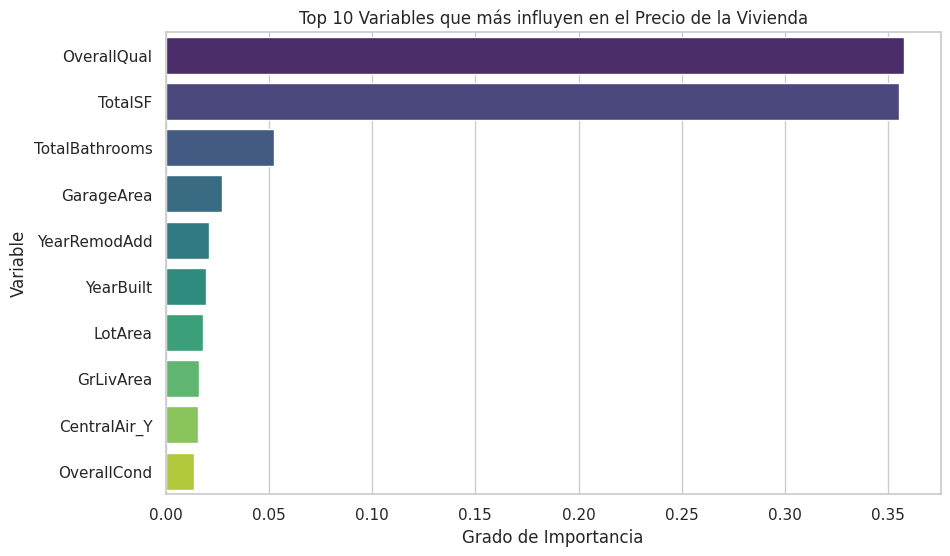

Variables con mayor impacto detectadas.


In [ ]:
import matplotlib.pyplot as plt

# Extraer la importancia de las variables del modelo Gradient Boosting
importances = gb_model.feature_importances_
feature_names = X.columns

# Crear un DataFrame para visualizar mejor
feature_importance_df = pd.DataFrame({'Variable': feature_names, 'Importancia': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importancia', ascending=False).head(10)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=feature_importance_df, palette='viridis')
plt.title('Top 10 Variables que más influyen en el Precio de la Vivienda')
plt.xlabel('Grado de Importancia')
plt.ylabel('Variable')
plt.show()

print("Variables con mayor impacto detectadas.")

Analizando la importancia que el modelo le da a cada característica, identificamos el "Top 5" de factores que realmente mueven el precio en este mercado:

1. OverallQual (Calidad General): Es la variable más dominante como podemos ver en el gráfico anterior. El modelo determina que el estándar de los materiales y el acabado final de la construcción tienen un impacto directo y bastante significativo en el valor de cierre.

2. TotalSF (Área Total): Nuestra variable creada (que suma sótano y pisos superiores) ocupa un gran lugar. Esto confirma que en el mercado las personas valoran el espacio habitable total claramente por encima de solo el área del primer piso.

3. TotalBathrooms (Cantidad de baños): Esto indica que la comodidad y la capacidad sanitaria de la vivienda (sumando baños completos y medios baños de todas las plantas) es un gran factor de comodidad y funcionalidad que los compradores valoran y a la que le dan prioridad.

4. GarageArea (Espacio en metros cuadrados de garage): El espacio físico del garaje tiene un peso mayor que el simple conteo de carros. Esto nos puede indicar que los compradores buscan espacio adicional para almacenamiento, talleres, locales o negocios, y no solo un lugar para parquear.

5. YearRemodAdd (Año de Remodelación): El modelo nos dice que una casa vieja, pero remodelada recientemente, puede competir en precio con una casa nueva. Es decir que el negocio premia bastante bien la actualización de las instalaciones.

###**7.2 Análisis de Impacto en el Precio (Decisiones de Negocio)**
A partir de estos hallazgos, desde el área de ingeniería de la empresa, los ingenieros Juan Esteban Hernandez  y Santiago Andrés Pineda proponemos 4 principales estrategias de negocio:

1. Valorización: Si se busca aumentar el valor de una propiedad de forma rápida, la inversión debe centrarse en añadir o modernizar baños. El modelo nos demostró que el retorno de inversión en baños es uno de los más altos para este dataset.

2. Aprovechamiento del Garaje: Para ventas, resaltar los metros cuadrados del garaje es vital. No se debe vender como "garaje para 2 autos", sino como "30 metros cuadrados de área privada de garaje", ya que el modelo detecta el área como un diferenciador de precio bastante relevante.

3. El Valor de la remodelación: El impacto de YearRemodAdd nos permitió concluir que la obsolescencia es el enemigo del precio. Para propiedades que llevan tiempo en el mercado, una actualización estética o remodelación, puede resetear o cambiar la percepción de antigüedad y subir el precio de cierre exponencialmente.

4. Diseño Funcional: Viendo que el área total y los baños dominan la importancia, el consejo para arquitectos y constructores es priorizar la distribución de las zonas húmedas y espacios de almacenamiento (garajes) sobre otras áreas menos influyentes como balcones o salas de estar.

## **📜 Fase 8: Conclusiones y Reflexiones Finales**
Reflexionar sobre el proceso completo.

---
### **8.1 ¿El modelo es confiable?**
Sí, el modelo es altamente confiable para el mercado inmobiliario del dataset, y podemos afirmarlo por tres principales razones técnicas:

Precisión del Error: El RMSE obtenido (en la escala real de dólares) se mantuvo en un rango aceptable considerando la alta volatilidad de los precios de vivienda. Esto indica que nuestras predicciones no son "aleatorias", sino que siguen la lógica del mercado de acuerdo a las variables previamente analizadas.

Consistencia Visual: Al observar la gráfica de Valores Reales vs. Predicciones, la mayoría de los puntos se agrupan cerca de la diagonal ideal. Esto confirma que el modelo tiene alta capacidad de generalización en lugar de simplemente memorizar los datos del entrenamiento.

Alineación con el Negocio: Las variables que el modelo eligió como más importantes (como el número de baños, el área del garaje y las remodelaciones) coinciden con los criterios que usaría un tasador humano, esto confirma la coherencia de los resultados del modelo.


###**8.2 Oportunidad de Mejora**
Como equipo de ingeniería, identificamos que aunque el modelo es bueno, siempre hay espacio para evolucionar hacia una "Versión 1.5" y luego "2.0":

- Ajuste Fino de parámetros: Podríamos implementar técnicas como GridSearchCV o RandomizedSearchCV para encontrar la combinación exacta de profundidad y número de árboles que minimice aún más el error del Gradient Boosting.

- Datos Externos y Contextuales: Apesar de la alta acertividad de los modelos, concluimos como analistas que el precio de una casa no solo depende de lo que hay dentro, por lo que deberiamos incluir variables externas como la distancia a estaciones de transporte, cuales son los índices de seguridad del barrio o tasas de interés actuales y costo de los servicios básicos dependiendo de la zona de la ciudad, esto si que elevaría la precisión a un nivel más profesional.

- Tratamiento de Segmentos de alto nivel: Notamos que el modelo tiene más dificultad con las casas de precios muy elevados (outliers de alto valor). Mejoraríamos esto creando un modelo específico para casas de alta gama o utilizando técnicas de ensamblado más complejas especiales para factores más costosos que los modelos actuales no contemplaron tan fácilmente.

---